# 时尚服饰图像分类模型训练

## 任务：10类服饰识别（T恤、裤子、套头衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包、踝靴）
## 架构：FashionCNN（7层自定义CNN） + FashionResNet（ResNet18迁移学习）
## 目标精度：≥80%


In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, os, sys, struct
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Auto-detect project root
def get_project_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(current, 'backend')) and os.path.exists(os.path.join(current, 'dataset')):
            return current
        parent = os.path.dirname(current)
        if parent == current: break
        current = parent
    return os.getcwd()
ROOT = get_project_root()
print(f'Project root: {ROOT}')

sys.path.insert(0, os.path.join(ROOT, 'backend', 'fashion_model'))
from model import get_model

import warnings as _w; _w.filterwarnings('ignore', category=UserWarning)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']


Project root: C:\Users\DOVE\python学习\大二下实训
Device: cuda


Train: (60000, 28, 28), Test: (10000, 28, 28)


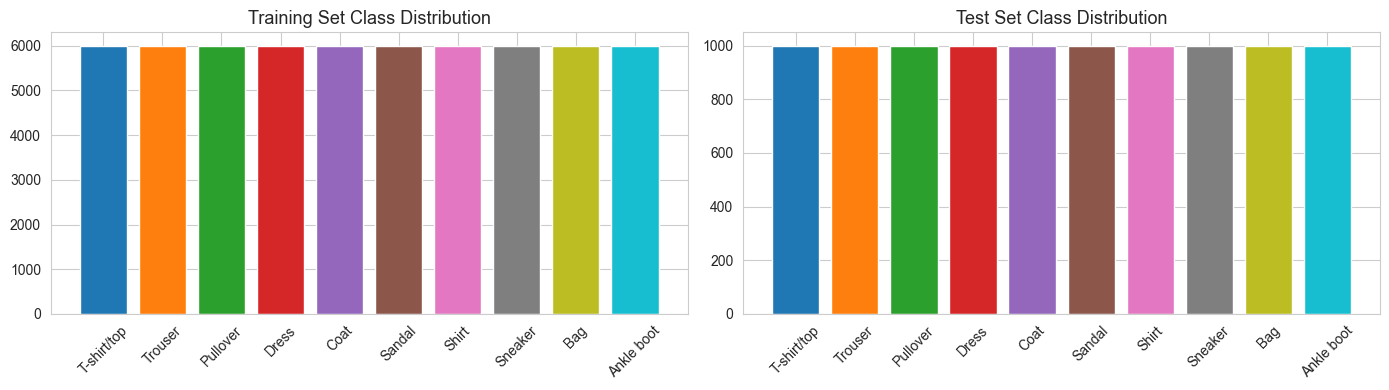

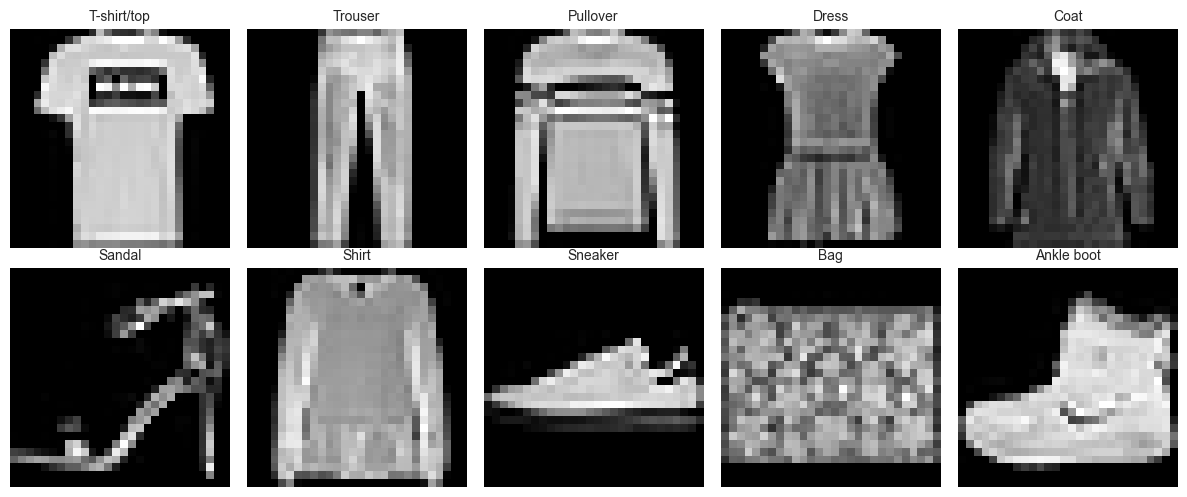

In [2]:
# ==================== 1. 加载本地IDX数据 ====================
def read_idx(fn):
    with open(fn,'rb') as f:
        _, dtype, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for _ in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

DATA_DIR = os.path.join(ROOT, 'dataset', 'cloths')
tr_img = read_idx(os.path.join(DATA_DIR, 'train-images-idx3-ubyte','train-images-idx3-ubyte'))
tr_lbl = read_idx(os.path.join(DATA_DIR, 'train-labels-idx1-ubyte','train-labels-idx1-ubyte'))
te_img = read_idx(os.path.join(DATA_DIR, 't10k-images-idx3-ubyte','t10k-images-idx3-ubyte'))
te_lbl = read_idx(os.path.join(DATA_DIR, 't10k-labels-idx1-ubyte','t10k-labels-idx1-ubyte'))
print(f'Train: {tr_img.shape}, Test: {te_img.shape}')

# 类别分布
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lbls, title in [(axes[0], tr_lbl, 'Training Set'), (axes[1], te_lbl, 'Test Set')]:
    counts = np.bincount(lbls)
    ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10(np.arange(10)), edgecolor='white')
    ax.set_title(f'{title} Class Distribution', fontsize=13); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'fashion_model', 'checkpoints', '01_data_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# 样本展示
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    idx = np.where(tr_lbl==i)[0][0]
    axes[i//5][i%5].imshow(tr_img[idx], cmap='gray')
    axes[i//5][i%5].set_title(CLASS_NAMES[i], fontsize=10); axes[i//5][i%5].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'fashion_model', 'checkpoints', '01_samples.png'), dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# ==================== 2. 数据预处理 ====================
MEAN, STD = 0.2860, 0.3530
tr_img = tr_img.astype(np.float32)/255.0; te_img = te_img.astype(np.float32)/255.0
tr_t = torch.tensor(tr_img).unsqueeze(1); tr_l = torch.tensor(tr_lbl, dtype=torch.long)
te_t = torch.tensor(te_img).unsqueeze(1); te_l = torch.tensor(te_lbl, dtype=torch.long)

# 验证集划分
val_size = int(0.1*len(tr_t))
indices = torch.randperm(len(tr_t), generator=torch.Generator().manual_seed(42))
v_idx, tr_idx = indices[:val_size], indices[val_size:]

class AugDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, labels, mean, std, augment=False):
        self.imgs, self.labels, self.mean, self.std, self.augment = imgs, labels, mean, std, augment
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        x, y = self.imgs[idx], self.labels[idx]
        if self.augment and torch.rand(1)>0.5: x = torch.flip(x, [2])
        return (x-self.mean)/self.std, y

BATCH = 128
tr_loader = DataLoader(AugDataset(tr_t[tr_idx], tr_l[tr_idx], MEAN, STD, True), BATCH, True)
v_loader  = DataLoader(AugDataset(tr_t[v_idx], tr_l[v_idx], MEAN, STD, False), BATCH, False)
te_loader  = DataLoader(AugDataset(te_t, te_l, MEAN, STD, False), BATCH, False)
print(f'Train: {len(tr_idx)} | Val: {len(v_idx)} | Test: {len(te_t)}')


Train: 54000 | Val: 6000 | Test: 10000


In [4]:
# ==================== 3. 训练工具函数 ====================
def f_train_ep(model, loader, crit, opt, dev):
    model.train(); loss_sum, correct, total = 0, 0, 0
    for x,y in loader:
        x,y=x.to(dev),y.to(dev); opt.zero_grad()
        loss=crit(model(x),y); loss.backward(); opt.step()
        loss_sum+=loss.item(); correct+=model(x).argmax(1).eq(y).sum().item(); total+=y.size(0)
    return loss_sum/len(loader), 100.*correct/total

@torch.no_grad()
def f_eval(model, loader, crit, dev):
    model.eval(); loss_sum, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for x,y in loader:
        x,y=x.to(dev),y.to(dev); out=model(x)
        loss_sum+=crit(out,y).item(); preds=out.argmax(1)
        correct+=preds.eq(y).sum().item(); total+=y.size(0)
        all_preds.extend(preds.cpu().numpy()); all_labels.extend(y.cpu().numpy())
    return loss_sum/len(loader), 100.*correct/total, all_preds, all_labels

def f_train(model, name, tr_loader, v_loader, epochs, dev):
    model=model.to(dev); crit=nn.CrossEntropyLoss(); opt=optim.Adam(model.parameters(), lr=0.001)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
    best_acc, best_st = 0, None
    for ep in range(epochs):
        tl,ta=f_train_ep(model,tr_loader,crit,opt,dev)
        vl,va,_,_=f_eval(model,v_loader,crit,dev); sched.step()
        for k,v in zip(['train_loss','train_acc','val_loss','val_acc'],[tl,ta,vl,va]): hist[k].append(v)
        print(f'[{name}] E{ep+1:2d}/{epochs} | TA={ta:.2f}% VA={va:.2f}%')
        if va>best_acc: best_acc=va; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_st)
    return model, hist, best_acc


In [5]:
# ==================== 4. 训练 CNN ====================
print('=== FashionCNN ===')
cnn_f = get_model('cnn', 10)
cnn_f, hist_cnn_f, acc_cnn_f = f_train(cnn_f, 'CNN', tr_loader, v_loader, 30, DEVICE)
_, te_acc_cnn_f, preds_cnn, labels_cnn = f_eval(cnn_f, te_loader, nn.CrossEntropyLoss(), DEVICE)
print(f'CNN Test Accuracy: {te_acc_cnn_f:.2f}%')


=== FashionCNN ===
[CNN] E 1/30 | TA=80.15% VA=85.87%
[CNN] E 2/30 | TA=87.89% VA=88.83%
[CNN] E 3/30 | TA=89.38% VA=90.32%
[CNN] E 4/30 | TA=90.44% VA=90.92%
[CNN] E 5/30 | TA=91.23% VA=91.57%
[CNN] E 6/30 | TA=91.66% VA=92.00%
[CNN] E 7/30 | TA=91.91% VA=91.70%
[CNN] E 8/30 | TA=92.30% VA=92.20%
[CNN] E 9/30 | TA=92.67% VA=92.85%
[CNN] E10/30 | TA=92.96% VA=92.90%
[CNN] E11/30 | TA=93.16% VA=93.18%
[CNN] E12/30 | TA=93.37% VA=93.50%
[CNN] E13/30 | TA=93.58% VA=93.20%
[CNN] E14/30 | TA=93.76% VA=93.37%
[CNN] E15/30 | TA=94.04% VA=93.97%
[CNN] E16/30 | TA=94.19% VA=93.78%
[CNN] E17/30 | TA=94.42% VA=93.78%
[CNN] E18/30 | TA=94.51% VA=94.03%
[CNN] E19/30 | TA=94.59% VA=94.02%
[CNN] E20/30 | TA=94.95% VA=94.10%
[CNN] E21/30 | TA=95.05% VA=94.30%
[CNN] E22/30 | TA=95.06% VA=94.03%
[CNN] E23/30 | TA=95.17% VA=94.25%
[CNN] E24/30 | TA=95.33% VA=94.32%
[CNN] E25/30 | TA=95.39% VA=94.25%
[CNN] E26/30 | TA=95.55% VA=94.43%
[CNN] E27/30 | TA=95.74% VA=94.32%
[CNN] E28/30 | TA=95.68% VA=94.38%
[

In [6]:
# ==================== 5. 训练 ResNet18 ====================
print('=== FashionResNet18 ===')
resnet_f = get_model('resnet18', 10)
resnet_f, hist_rn_f, acc_rn_f = f_train(resnet_f, 'ResNet18', tr_loader, v_loader, 30, DEVICE)
_, te_acc_rn_f, preds_rn, labels_rn = f_eval(resnet_f, te_loader, nn.CrossEntropyLoss(), DEVICE)
print(f'ResNet18 Test Accuracy: {te_acc_rn_f:.2f}%')


=== FashionResNet18 ===
[ResNet18] E 1/30 | TA=84.99% VA=85.78%
[ResNet18] E 2/30 | TA=89.26% VA=86.57%
[ResNet18] E 3/30 | TA=90.62% VA=88.27%
[ResNet18] E 4/30 | TA=91.70% VA=90.00%
[ResNet18] E 5/30 | TA=92.36% VA=90.72%
[ResNet18] E 6/30 | TA=92.90% VA=90.37%
[ResNet18] E 7/30 | TA=93.46% VA=90.33%
[ResNet18] E 8/30 | TA=94.01% VA=91.38%
[ResNet18] E 9/30 | TA=94.43% VA=90.97%
[ResNet18] E10/30 | TA=94.88% VA=90.73%
[ResNet18] E11/30 | TA=95.35% VA=91.78%
[ResNet18] E12/30 | TA=95.84% VA=91.65%
[ResNet18] E13/30 | TA=96.43% VA=91.73%
[ResNet18] E14/30 | TA=96.79% VA=91.78%
[ResNet18] E15/30 | TA=97.27% VA=91.93%
[ResNet18] E16/30 | TA=97.83% VA=92.18%
[ResNet18] E17/30 | TA=98.23% VA=92.03%
[ResNet18] E18/30 | TA=98.54% VA=92.13%
[ResNet18] E19/30 | TA=98.85% VA=92.08%
[ResNet18] E20/30 | TA=99.16% VA=92.07%
[ResNet18] E21/30 | TA=99.34% VA=92.35%
[ResNet18] E22/30 | TA=99.52% VA=92.58%
[ResNet18] E23/30 | TA=99.67% VA=92.58%
[ResNet18] E24/30 | TA=99.77% VA=92.42%
[ResNet18] E25/3

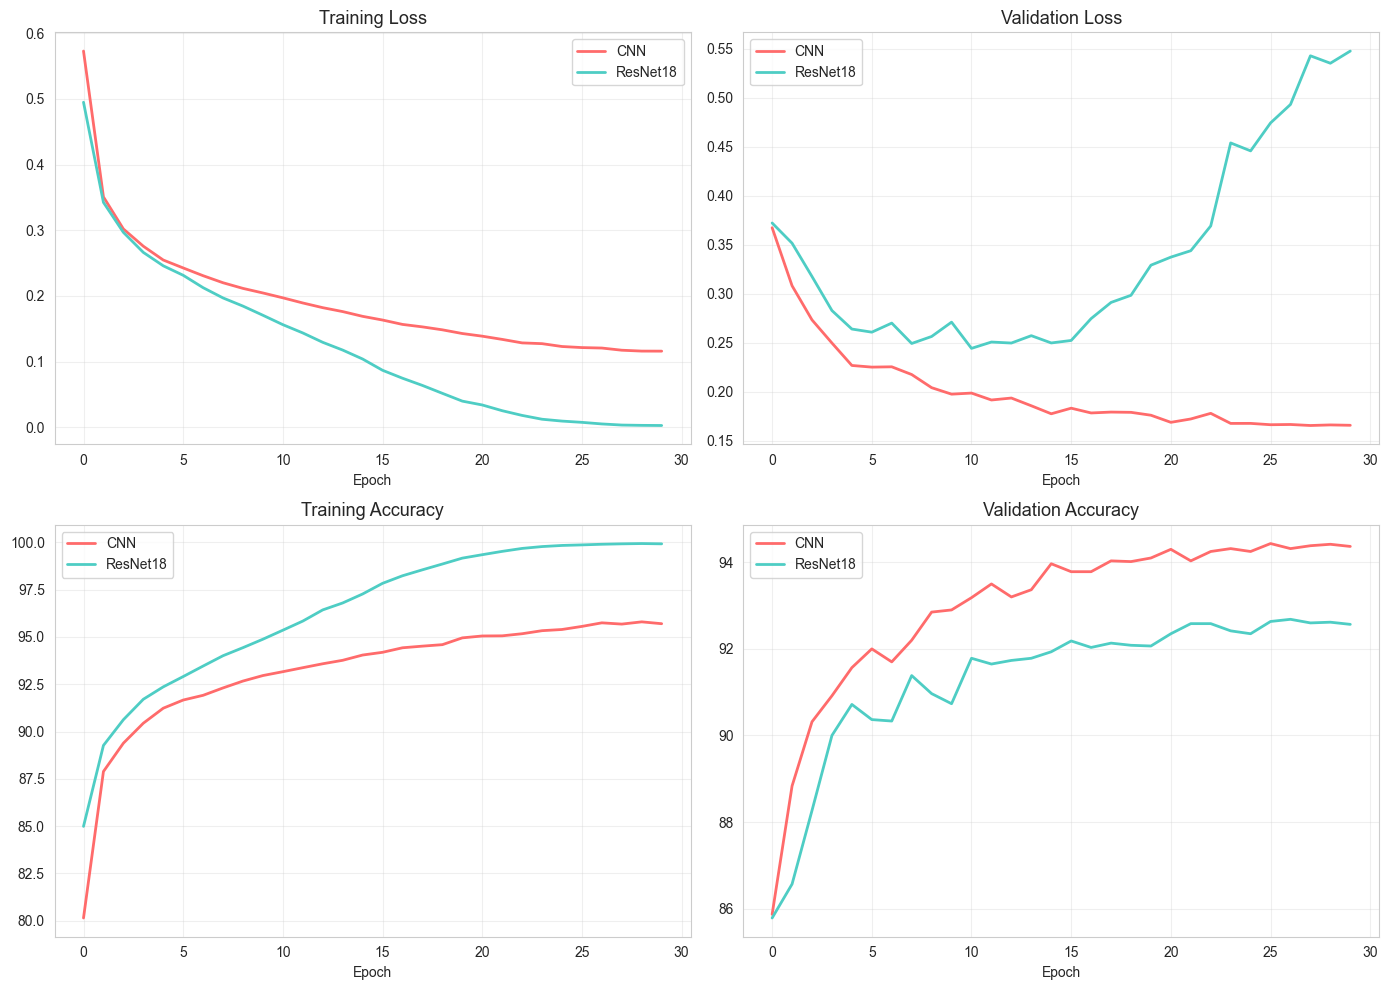

In [7]:
# ==================== 6. 训练曲线对比 ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key, title in [(axes[0,0],'train_loss','Training Loss'), (axes[0,1],'val_loss','Validation Loss'),
                        (axes[1,0],'train_acc','Training Accuracy'), (axes[1,1],'val_acc','Validation Accuracy')]:
    ax.plot(hist_cnn_f[key], label='CNN', color='#FF6B6B', linewidth=2)
    ax.plot(hist_rn_f[key], label='ResNet18', color='#4ECDC4', linewidth=2)
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'fashion_model', 'checkpoints', '02_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


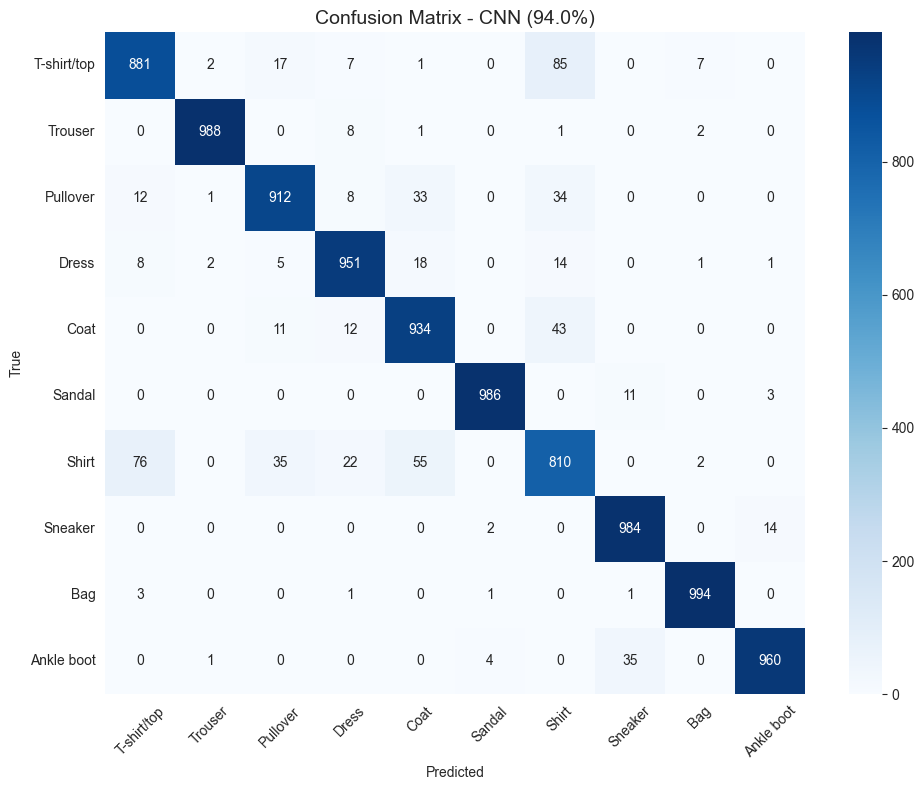

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.88      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.93      0.91      0.92      1000
       Dress       0.94      0.95      0.95      1000
        Coat       0.90      0.93      0.91      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.82      0.81      0.82      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [8]:
# ==================== 7. 混淆矩阵 ====================
best_f = cnn_f if te_acc_cnn_f >= te_acc_rn_f else resnet_f
best_p = preds_cnn if te_acc_cnn_f >= te_acc_rn_f else preds_rn
best_l = labels_cnn if te_acc_cnn_f >= te_acc_rn_f else labels_rn
bname = 'CNN' if te_acc_cnn_f >= te_acc_rn_f else 'ResNet18'

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(best_l, best_p)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - {bname} ({max(te_acc_cnn_f, te_acc_rn_f):.1f}%)', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'fashion_model', 'checkpoints', '03_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(best_l, best_p, target_names=CLASS_NAMES))


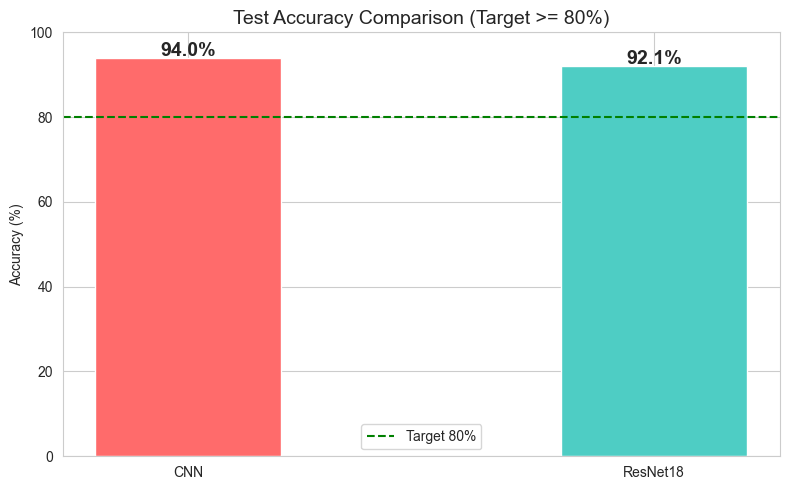

Saved. CNN: 94.0% | ResNet18: 92.1%


In [9]:
# ==================== 8. 精度对比与保存 ====================
fig, ax = plt.subplots(figsize=(8, 5))
models_f = ['CNN', 'ResNet18']
accs_f = [te_acc_cnn_f, te_acc_rn_f]
bars = ax.bar(models_f, accs_f, color=['#FF6B6B','#4ECDC4'], edgecolor='white', width=0.4)
for b, v in zip(bars, accs_f): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=14)
ax.axhline(y=80, color='green', linestyle='--', label='Target 80%'); ax.legend()
ax.set_ylabel('Accuracy (%)'); ax.set_title('Test Accuracy Comparison (Target >= 80%)', fontsize=14); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'fashion_model', 'checkpoints', '04_accuracy_compare.png'), dpi=150, bbox_inches='tight')
plt.show()

CKPT = os.path.join(ROOT, 'backend', 'fashion_model', 'checkpoints')
torch.save({
    'cnn_state_dict': {k:v.cpu().clone() for k,v in cnn_f.state_dict().items()},
    'resnet18_state_dict': {k:v.cpu().clone() for k,v in resnet_f.state_dict().items()},
    'num_classes':10, 'class_names':CLASS_NAMES,
    'test_accuracy_cnn': te_acc_cnn_f/100., 'test_accuracy_resnet18': te_acc_rn_f/100.,
}, os.path.join(CKPT, 'best_model.pth'))
print(f'Saved. CNN: {te_acc_cnn_f:.1f}% | ResNet18: {te_acc_rn_f:.1f}%')
